In [1]:
import pandas as pd
import numpy as np
import time
import shap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

In [2]:
# loading the data from CSV file to a Pandas Dataframe
calories = pd.read_csv('calories.csv')
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [3]:
exercise_data = pd.read_csv('exercise.csv')
exercise_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [4]:
# combining the two datas
calories_data = pd.concat([exercise_data, calories['Calories']], axis = 1)
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [5]:
calories_data = calories_data.drop(columns = ['User_ID'], axis = 1)

In [6]:
calories_data.shape

(15000, 8)

In [7]:
calories_data.replace({'Gender' :{'male' :0, 'female' :1}}, inplace = True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_3352\3984358361.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  calories_data.replace({'Gender' :{'male' :0, 'female' :1}}, inplace = True)


In [8]:
X = calories_data.drop(columns = ['Calories'], axis = 1)
Y = calories_data['Calories']

In [9]:
X_train, X_test, Y_train, Y_test =  train_test_split(X, Y, test_size = 0.2)

In [10]:
X_train.shape
X_test.shape

(3000, 7)

C:\Users\DELL\AppData\Local\Temp\ipykernel_3352\2539438794.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')


🔍 Correlation of features with 'Calories':
Duration      0.955421
Heart_Rate    0.897882
Body_Temp     0.824558
Age           0.154395
Weight        0.035481
Height        0.017537
Gender       -0.022357
Name: Calories, dtype: float64


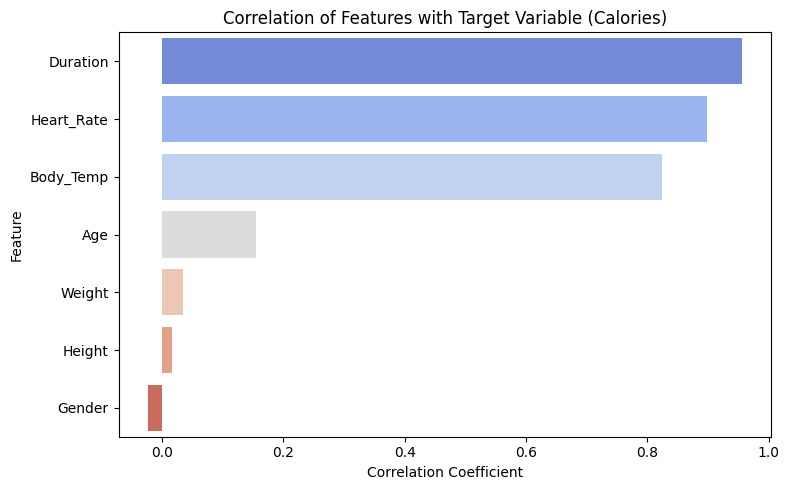

In [11]:
# Calculate correlation matrix
corr_matrix = calories_data.corr()

# Extract correlations with the target variable 'Calories'
target_corr = corr_matrix['Calories'].drop('Calories').sort_values(ascending=False)

# Display top features
print("🔍 Correlation of features with 'Calories':")
print(target_corr)

# Plot correlation with Calories
plt.figure(figsize=(8, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')
plt.title("Correlation of Features with Target Variable (Calories)")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [12]:
# Models to evaluate
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=20),
    "XGBoost": XGBRegressor(n_estimators=100, max_depth=20, learning_rate=0.5, objective='reg:squarederror'),
    "LGBM": LGBMRegressor(n_estimators=100, max_depth=20, learning_rate=0.5),
    "KNN": KNeighborsRegressor(n_neighbors=5, weights='uniform')
}

results = []

In [13]:
# Evaluate each model
preds_test = [] 
preds_train = []

for name, model in models.items():
    print(f"\n\u2728 Training {name}...")
    model.fit(X_train, Y_train)

    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)

    preds_train.append(Y_train_pred)
    preds_test.append(Y_test_pred)

    train_mae = mean_absolute_error(Y_train, Y_train_pred)
    test_mae = mean_absolute_error(Y_test, Y_test_pred)
    train_r2 = r2_score(Y_train, Y_train_pred)
    test_r2 = r2_score(Y_test, Y_test_pred)

    print(f"Train MAE: {train_mae:.2f}, R2: {train_r2:.4f}")
    print(f"Test MAE: {test_mae:.2f}, R2: {test_r2:.4f}")

    results.append({
        "Model": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train R2": train_r2,
        "Test R2": test_r2,

    })


✨ Training Linear Regression...
Train MAE: 8.31, R2: 0.9673
Test MAE: 8.45, R2: 0.9666

✨ Training Random Forest...
Train MAE: 0.67, R2: 0.9997
Test MAE: 1.68, R2: 0.9981

✨ Training XGBoost...
Train MAE: 0.00, R2: 1.0000
Test MAE: 2.17, R2: 0.9972

✨ Training LGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000532 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 367
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 7
[LightGBM] [Info] Start training from score 89.518083
Train MAE: 1.03, R2: 0.9995
Test MAE: 1.60, R2: 0.9986

✨ Training KNN...
Train MAE: 4.24, R2: 0.9909
Test MAE: 5.08, R2: 0.9872


In [14]:
# --- Averaging Ensemble ---
print("\n Evaluating Averaging Ensemble Model...")

# Convert prediction lists to numpy arrays
avg_train_pred = np.mean(preds_train, axis=0)
avg_test_pred = np.mean(preds_test, axis=0)

ensemble_train_mae = mean_absolute_error(Y_train, avg_train_pred)
ensemble_test_mae = mean_absolute_error(Y_test, avg_test_pred)
ensemble_train_r2 = r2_score(Y_train, avg_train_pred)
ensemble_test_r2 = r2_score(Y_test, avg_test_pred)

print(f"Averaging Ensemble - Train MAE: {ensemble_train_mae:.2f}, R2: {ensemble_train_r2:.4f}")
print(f"Averaging Ensemble - Test MAE: {ensemble_test_mae:.2f}, R2: {ensemble_test_r2:.4f}")

results.append({
    "Model": "Averaging Ensemble",
    "Train MAE": ensemble_train_mae,
    "Test MAE": ensemble_test_mae,
    "Train R2": ensemble_train_r2,
    "Test R2": ensemble_test_r2,
})


 Evaluating Averaging Ensemble Model...
Averaging Ensemble - Train MAE: 2.09, R2: 0.9978
Averaging Ensemble - Test MAE: 2.51, R2: 0.9967


In [15]:
# --- Averaging Ensemble (for XGBoost and LGBM only) ---
print("\nEvaluating Averaging Ensemble Model (XGBoost + LGBM)...")

# Extract predictions for only XGBoost and LGBM
xgb_train_pred = preds_train[2]
lgbm_train_pred = preds_train[3]

xgb_test_pred = preds_test[2]
lgbm_test_pred = preds_test[3]

# Calculate average predictions for training and test data
avg_train_pred = np.mean([xgb_train_pred, lgbm_train_pred], axis=0)
avg_test_pred = np.mean([xgb_test_pred, lgbm_test_pred], axis=0)

# Evaluate ensemble model's performance
ensemble_train_mae = mean_absolute_error(Y_train, avg_train_pred)
ensemble_test_mae = mean_absolute_error(Y_test, avg_test_pred)
ensemble_train_r2 = r2_score(Y_train, avg_train_pred)
ensemble_test_r2 = r2_score(Y_test, avg_test_pred)

# Print the results
print(f"Averaging Ensemble - Train MAE: {ensemble_train_mae:.2f}, R2: {ensemble_train_r2:.4f}")
print(f"Averaging Ensemble - Test MAE: {ensemble_test_mae:.2f}, R2: {ensemble_test_r2:.4f}")

# Append results to the results list
results.append({
    "Model": "Averaging Ensemble (XGBoost + LGBM)",
    "Train MAE": ensemble_train_mae,
    "Test MAE": ensemble_test_mae,
    "Train R2": ensemble_train_r2,
    "Test R2": ensemble_test_r2,
})


Evaluating Averaging Ensemble Model (XGBoost + LGBM)...
Averaging Ensemble - Train MAE: 0.52, R2: 0.9999
Averaging Ensemble - Test MAE: 1.43, R2: 0.9988


In [16]:
# Results Summary
df_results = pd.DataFrame(results)
print("\n\U0001F4CB Model Performance Summary:")
print(df_results)


📋 Model Performance Summary:
                                 Model  Train MAE  Test MAE  Train R2  \
0                    Linear Regression   8.305620  8.450569  0.967342   
1                        Random Forest   0.665587  1.682688  0.999705   
2                              XGBoost   0.000714  2.168331  1.000000   
3                                 LGBM   1.032990  1.596005  0.999494   
4                                  KNN   4.235167  5.075667  0.990916   
5                   Averaging Ensemble   2.085611  2.507312  0.997809   
6  Averaging Ensemble (XGBoost + LGBM)   0.516530  1.433332  0.999874   

    Test R2  
0  0.966622  
1  0.998117  
2  0.997215  
3  0.998625  
4  0.987178  
5  0.996724  
6  0.998816  


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000383 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 367
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 7
[LightGBM] [Info] Start training from score 89.518083


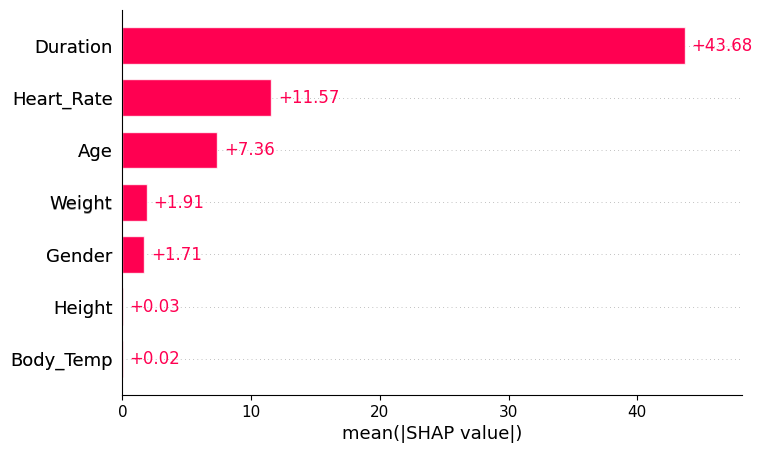

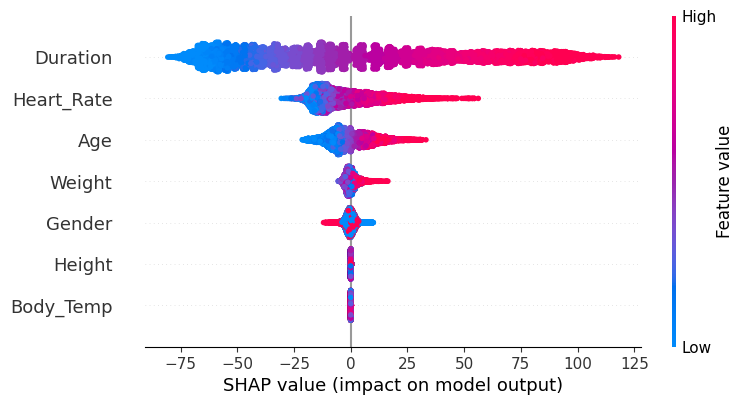

In [17]:
# Fit the final model (if not already done)
final_model = LGBMRegressor()
final_model.fit(X_train, Y_train)

# Use SHAP TreeExplainer for tree-based models like LGBM
explainer = shap.Explainer(final_model)
shap_values = explainer(X_train)

# Plot feature importance (global explanation)
plt.figure(figsize=(8, 8))
shap.plots.bar(shap_values)

# Beeswarm plot for detailed distribution
plt.figure(figsize=(8, 8))
shap.plots.beeswarm(shap_values)

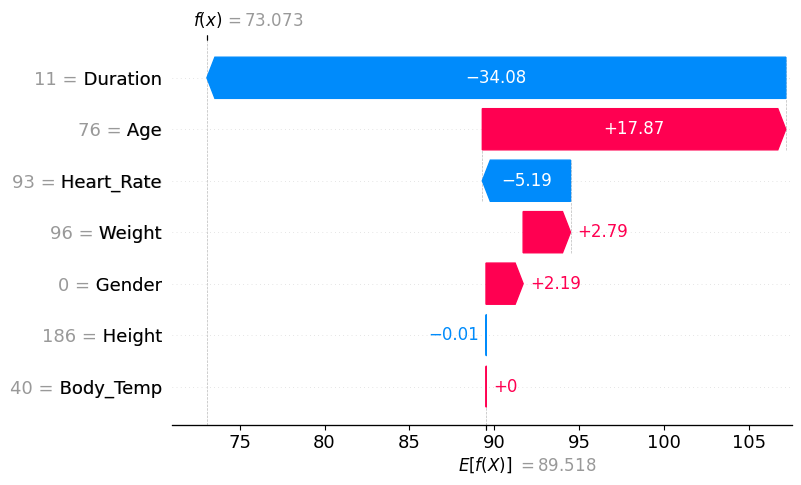

In [18]:
#Impact on Features on Final Output for 1 instance

instance_index = 0
instance = X_test.iloc[[instance_index]]

shap_value_single = explainer(instance)

shap.plots.force(shap_value_single)

shap.plots.waterfall(shap_value_single[0])

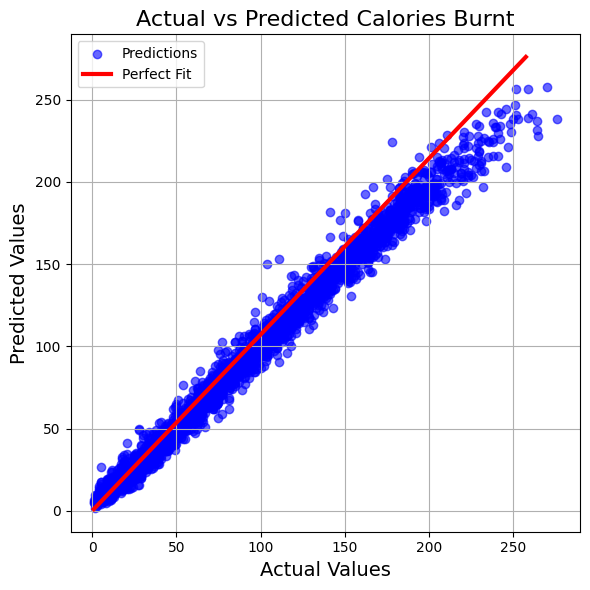

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, Y_test_pred, color='blue', label='Predictions', alpha=0.6)
plt.plot([Y_test.min(), Y_test_pred.max()], [Y_test.min(), Y_test.max()], color='red', linewidth=3, label='Perfect Fit')

# Labeling
plt.xlabel('Actual Values', fontsize=14)
plt.ylabel('Predicted Values', fontsize=14)
plt.title('Actual vs Predicted Calories Burnt', fontsize=16)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
# expected value E(f(x)) as the mean prediction on training data
expected_value = best_model.predict(X_train).mean()
print(f"E(f(x)) = {expected_value:.2f} calories")

E(f(x)) = 89.52 calories


In [22]:
# --- Manual Prediction ---
print("\n🔍 Manual Input for Calorie Prediction")

# Collect inputs (you can replace input() with fixed values during testing)
manual_input = {
    'Gender': int(input("Gender (0 for Male, 1 for Female): ")),
    'Age': int(input("Age: ")),
    'Height': float(input("Height (in cm): ")),
    'Weight': float(input("Weight (in kg): ")),
    'Duration': float(input("Exercise Duration (in minutes): ")),
    'Heart_Rate': float(input("Heart Rate: ")),
    'Body_Temp': float(input("Body Temperature (in °C): "))
}

# Convert to DataFrame
input_df = pd.DataFrame([manual_input])

# Select best model
best_model = models['LGBM'] 

# Predict calories burned
predicted_calories = best_model.predict(input_df)[0]
print(f"\n Estimated Calories Burned: {predicted_calories:.2f} Cal")


🔍 Manual Input for Calorie Prediction


Gender (0 for Male, 1 for Female):  1
Age:  30
Height (in cm):  180
Weight (in kg):  75
Exercise Duration (in minutes):  15
Heart Rate:  110
Body Temperature (in °C):  45



 Estimated Calories Burned: 92.26 Cal
